# Analysing rain and cluster data

In [6]:
import fiona
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pickle
from time import time
from tqdm import tqdm
import xarray as xr
import torch
import torch.nn as nn
import matplotlib.colors as colors
from torch import optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.tree import plot_tree
import seaborn as sns

from climate_dataset import load_data

seed = 1234
np.random.seed(seed)

ImportError: cannot import name 'load_data' from 'climate_dataset' (/mnt/cs/cs152/individual/hwalters/ML_rain_prediction/climate_dataset.py)

In [5]:
from climate_dataset import *
ppt_directory = "data/ppt-nc-1895-2020"
ppt_df, lat, lon = load_data(ppt_directory, dtype="ppt")

NameError: name 'load_data' is not defined

In [ ]:
def show_states(west_coast=True, state_file="States/cb_2018_us_state_20m.shp"):
    shape = fiona.open(state_file)
    for s in shape:
        pts = s["geometry"]["coordinates"]
        for p in pts:
            state = np.array(p).squeeze()
            if state[:, 1].min() < 50 and state[:, 1].min() > 22:
                if not west_coast:
                    plt.plot(state[:, 0], state[:, 1], color="black")
                elif np.max(state[:, 0]) < -100:  # plot only west coast
                    plt.plot(state[:, 0], state[:, 1], color="black")

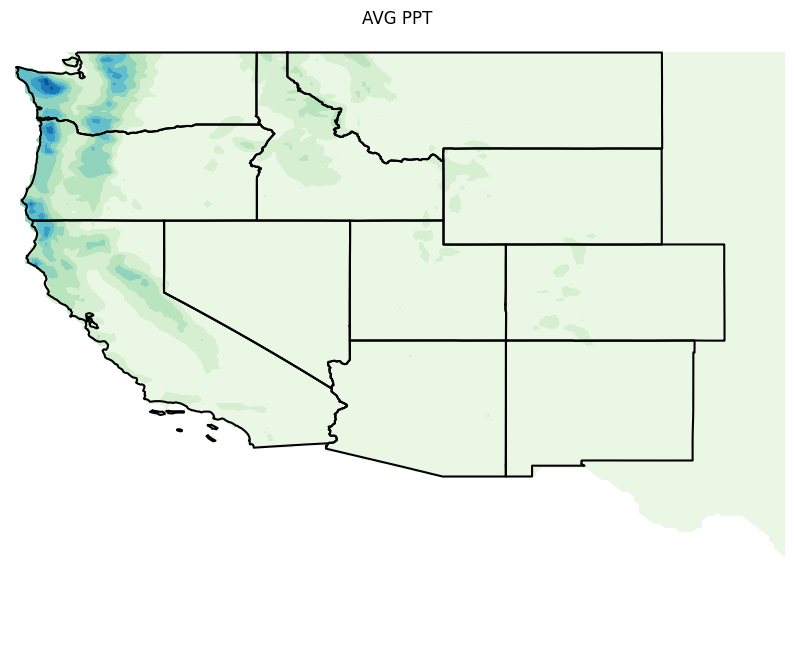

In [ ]:
avg_ppt = ppt_df["ppt"].mean()

plt.figure(figsize=(10, 8))
xx, yy = np.meshgrid(lon, lat)
plt.contourf(xx, yy, avg_ppt, cmap="GnBu")
show_states()
plt.axis("off")
plt.title("AVG PPT")
plt.show()
plt.close()

In [ ]:
def add_time(df):
    """Add Time Column"""
    min_year = np.min(df["Y"])
    df["T"] = (df["Y"] - min_year) * 12 + df["M"]
    return df


def add_season(df):
    """adds Season Column (0 for months 1,2,3 and 1 for months 10,11,12)"""
    df["season"] = ((df["M"] - 1) // 4).astype(bool).astype(int)
    return df


ppt_df = add_season(add_time(ppt_df))
ppt_df.to_csv("data/df.csv", index=False)


## Load the clusters

In [ ]:
clusters = np.load("clusters.npy")
clusters.shape

(155, 150)

In [ ]:
ppt_df["ppt_cluster"] = ppt_df["ppt"].apply(lambda x: average_clusters(x, clusters))
ppt_df["ppt_cluster_vector"] = ppt_df["ppt"].apply(
    lambda x: average_clusters(x, clusters, return_image=False)[:-1]
)

avg_clusters = average_clusters(ppt_df.iloc[0].ppt, clusters)
avg_clusters

/Users/hayleywalters/Desktop/research 2025/ML_rain_prediction/climate_dataset.py:433: RuntimeWarning: invalid value encountered in divide
  cluster_average = np.sum(masked_image) / cluster_size
/Users/hayleywalters/Desktop/research 2025/ML_rain_prediction/climate_dataset.py:433: RuntimeWarning: invalid value encountered in divide
  cluster_average = np.sum(masked_image) / cluster_size
/Users/hayleywalters/Desktop/research 2025/ML_rain_prediction/climate_dataset.py:433: RuntimeWarning: invalid value encountered in divide
  cluster_average = np.sum(masked_image) / cluster_size


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
# Assuming clusters, lon, lat, ppt_df are already loaded
# Select relevant months (1, 2, 3, 10, 11, 12)
relevant_months = [1, 2, 3, 10, 11, 12]
filtered_data = ppt_df[ppt_df['M'].isin(relevant_months)]

In [ ]:
filtered_data.head()

,F,Y,M,ppt,T,season,ppt_cluster,ppt_cluster_vector
0,ppt_1895_01.nc,1895,1,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...",1,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[24.32815200172811, 64.9120348914195, 15.76888..."
1,ppt_1895_02.nc,1895,2,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...",2,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[17.00794750864055, 23.741291628045552, 15.689..."
2,ppt_1895_03.nc,1895,3,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...",3,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[10.80709215389785, 10.713827876721398, 15.139..."
3,ppt_1895_10.nc,1895,10,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...",10,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[8.014168406778033, 23.0436184123411, 6.354248..."
4,ppt_1895_11.nc,1895,11,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...",11,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[22.563040034562214, 47.07612221927966, 21.645..."


In [ ]:
# Compute the average precipitation per cluster for each relevant month
avg_clusters = np.array([average_clusters(image, clusters) for image in filtered_data['ppt']])
avg_clusters.shape

/Users/hayleywalters/Desktop/research 2025/ML_rain_prediction/climate_dataset.py:433: RuntimeWarning: invalid value encountered in divide
  cluster_average = np.sum(masked_image) / cluster_size


(759, 155, 150)

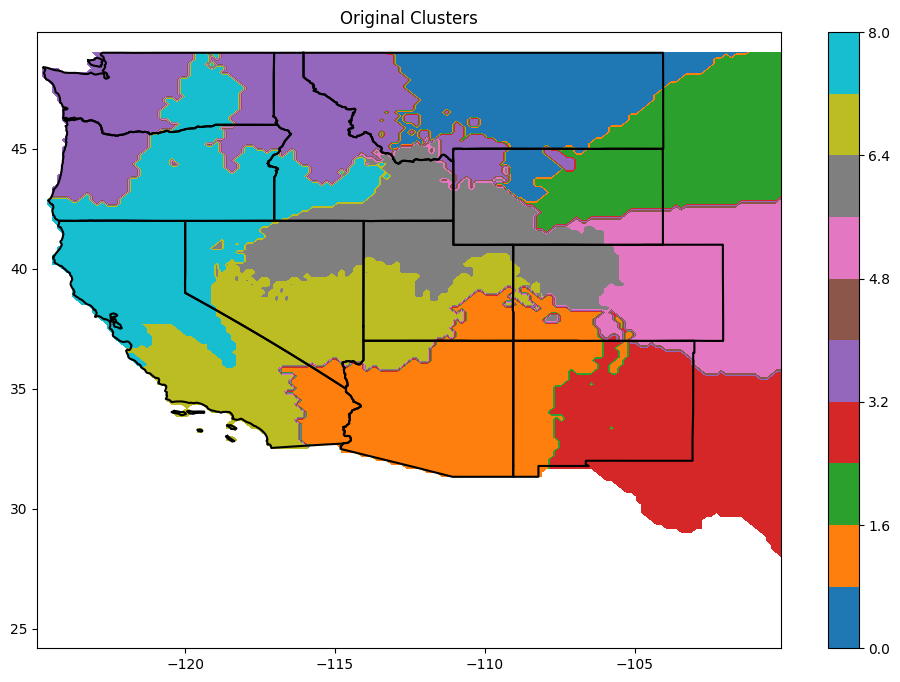

In [ ]:
# Step 1: Visualize the original cluster map
plt.figure(figsize=(12, 8))
xx, yy = np.meshgrid(lon, lat)
plt.contourf(xx, yy, clusters, levels=10, cmap="tab10")
plt.colorbar()
plt.title("Original Clusters")
show_states()
plt.show()

Compute the average precipitation per cluster for each relevant month

In [ ]:
# Compute the average precipitation per cluster for each relevant month
avg_clusters = np.array([average_clusters(image, clusters) for image in filtered_data['ppt']])
avg_clusters.shape

(759, 155, 150)

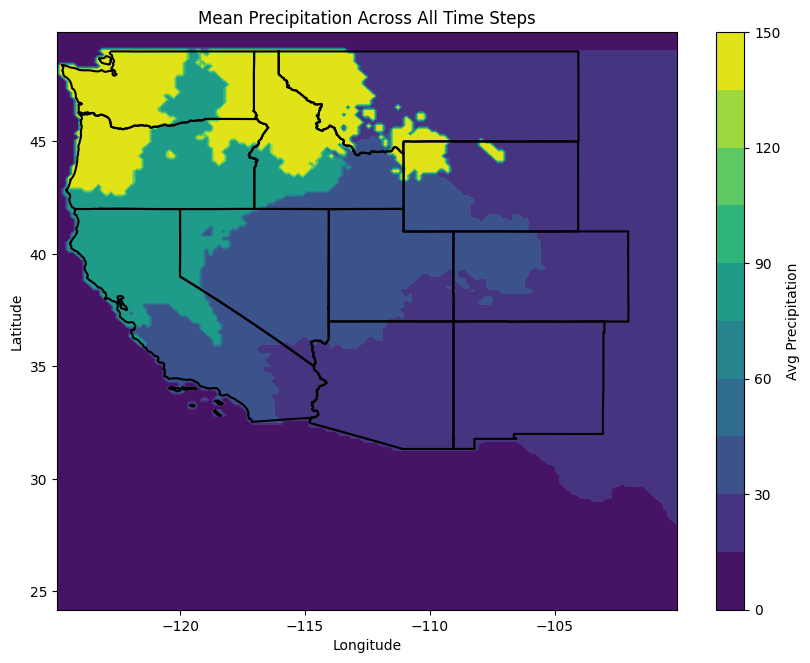

In [ ]:
# Compute the mean precipitation per cluster over all time steps
mean_precip_per_pixel = np.mean(avg_clusters, axis=0)  # Shape (155, 150)
import numpy as np
import matplotlib.pyplot as plt

# Plot the mean precipitation per pixel
plt.figure(figsize=(10, 7.5))
xx, yy = np.meshgrid(lon, lat)
plt.contourf(xx, yy, mean_precip_per_pixel, levels=10, cmap="viridis")  # Adjust levels for clarity
plt.colorbar(label="Avg Precipitation")
show_states()
plt.title("Mean Precipitation Across All Time Steps")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()



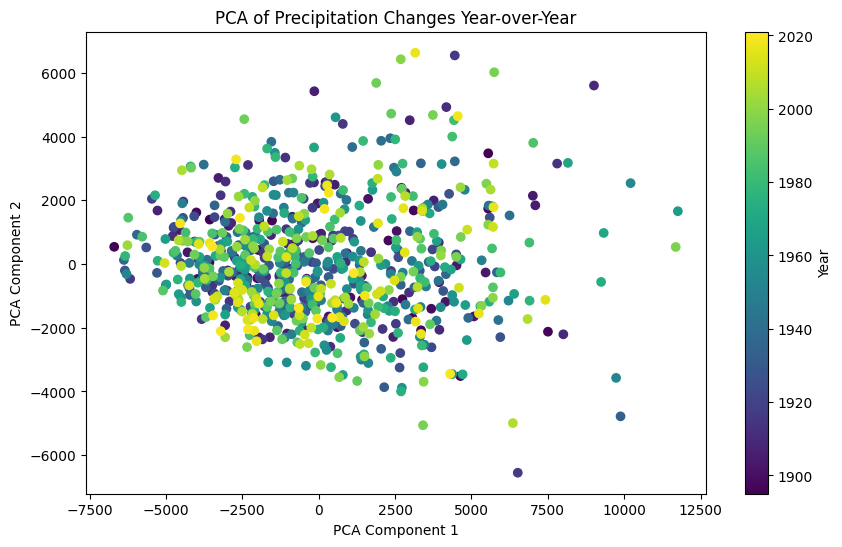

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Step 2: PCA for Year-over-Year Precipitation Changes
# Apply PCA on the precipitation data per cluster for all months
pca = PCA(n_components=2)  # Reduce to 2 components for easier visualization
pca_result = pca.fit_transform(avg_clusters.reshape(avg_clusters.shape[0], -1))  # Flatten for PCA

# Visualize the PCA results
plt.figure(figsize=(10, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=filtered_data['Y'], cmap='viridis')
plt.colorbar(label='Year')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA of Precipitation Changes Year-over-Year')
plt.show()


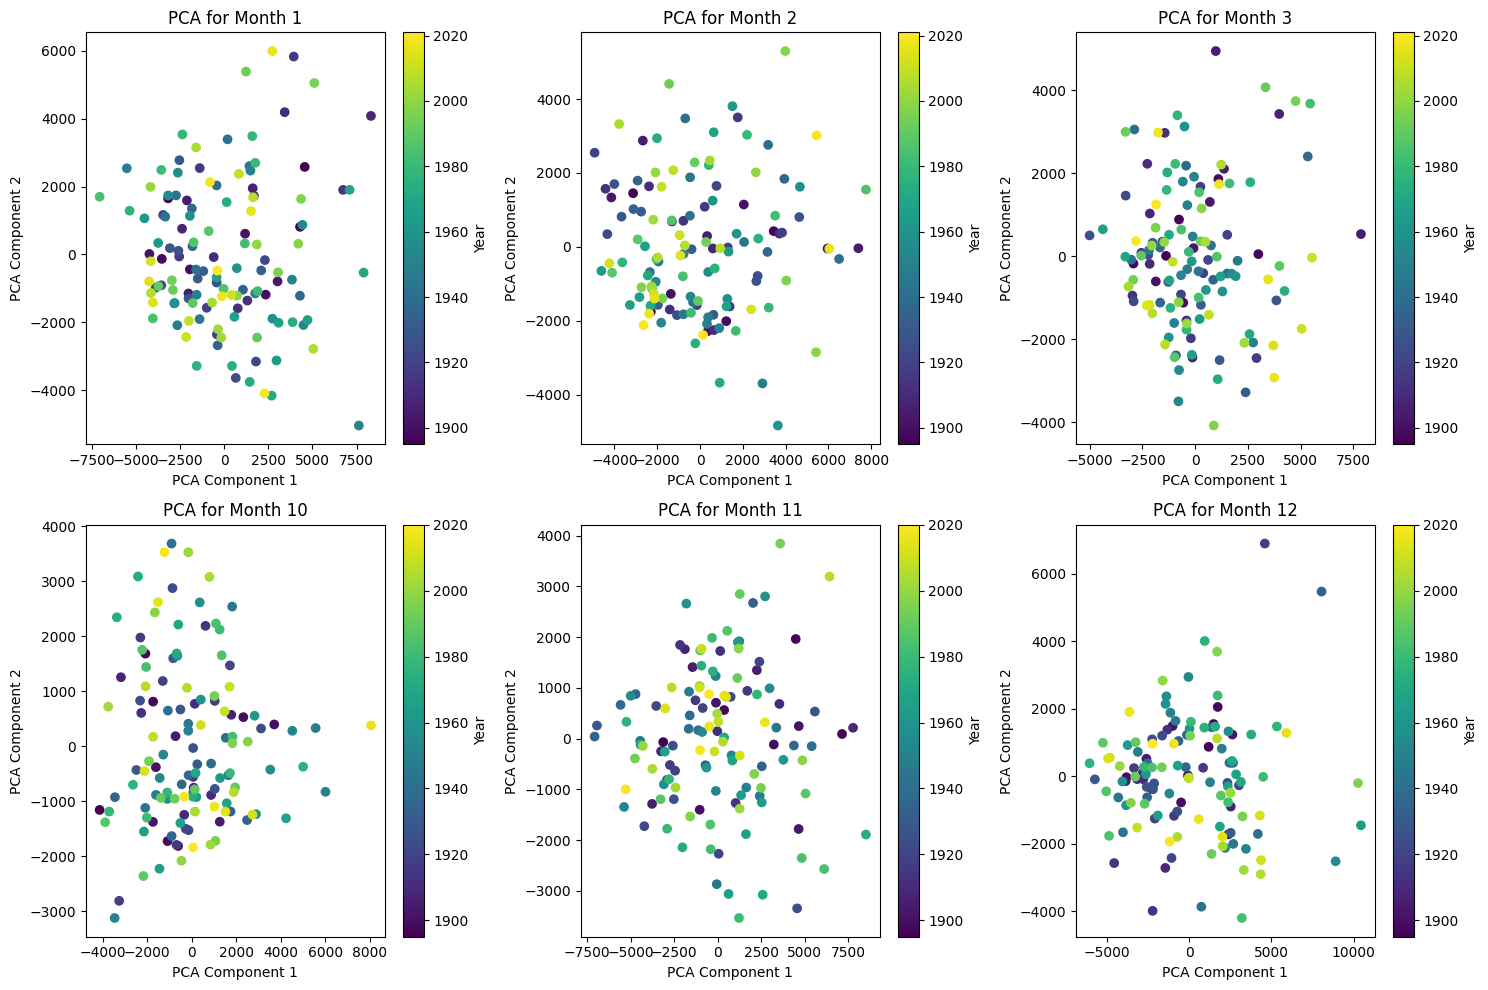

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Define the months of interest
months_of_interest = [1, 2, 3, 10, 11, 12]

# Set up the figure
fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 2 rows, 3 columns
axes = axes.ravel()  # Flatten to easily index

# Loop through each month and apply PCA
for i, month in enumerate(months_of_interest):
    # Filter data for the current month
    month_mask = filtered_data['M'] == month
    month_data = avg_clusters[month_mask]  # Select only the data for this month

    # Apply PCA
    pca = PCA(n_components=2)  
    pca_result = pca.fit_transform(month_data.reshape(month_data.shape[0], -1))  # Flatten for PCA

    # Scatter plot in the corresponding subplot
    ax = axes[i]
    scatter = ax.scatter(pca_result[:, 0], pca_result[:, 1], c=filtered_data['Y'][month_mask], cmap='viridis')
    ax.set_title(f'PCA for Month {month}')
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')

    # Add colorbar
    cbar = fig.colorbar(scatter, ax=ax)
    cbar.set_label('Year')

# Adjust layout
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the months of interest
months_of_interest = [1, 2, 3, 10, 11, 12]

# Extract cluster-wise averages and reshape into a long format DataFrame
data_list = []
for i, month in enumerate(months_of_interest):
    month_mask = filtered_data['M'] == month
    month_data = avg_clusters[month_mask]  # Shape: (num_samples, 155, 150)
    
    # Compute mean precipitation per cluster for each sample
    month_cluster_avg = np.array([average_clusters(img, clusters) for img in month_data])  # Shape: (num_samples, 8)
    
    # Create a DataFrame for this month
    df = pd.DataFrame(month_cluster_avg, columns=[f"Cluster {i}" for i in range(8)])
    df["Month"] = month
    data_list.append(df)

# Combine all months into one DataFrame
df_melted = pd.concat(data_list).melt(id_vars=["Month"], var_name="Cluster", value_name="Precipitation")

# Plot
plt.figure(figsize=(12, 6))
sns.boxplot(x="Month", y="Precipitation", hue="Cluster", data=df_melted, palette="tab10")
plt.title("Precipitation Distribution by Cluster (Month by Month)")
plt.xlabel("Month")
plt.ylabel("Precipitation")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


NameError: name 'filtered_data' is not defined

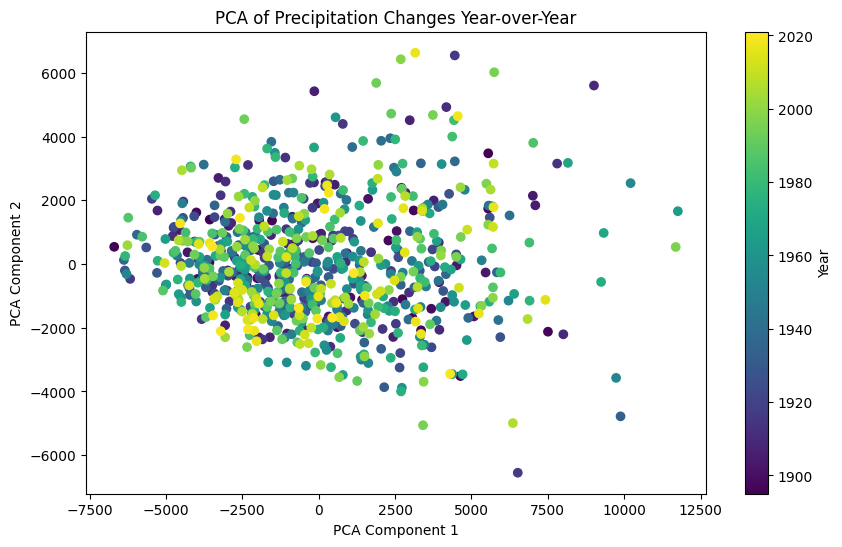

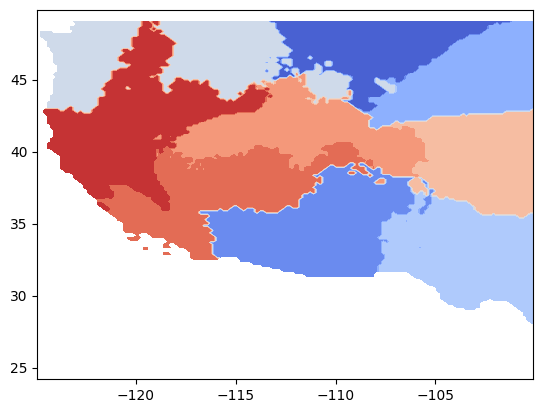

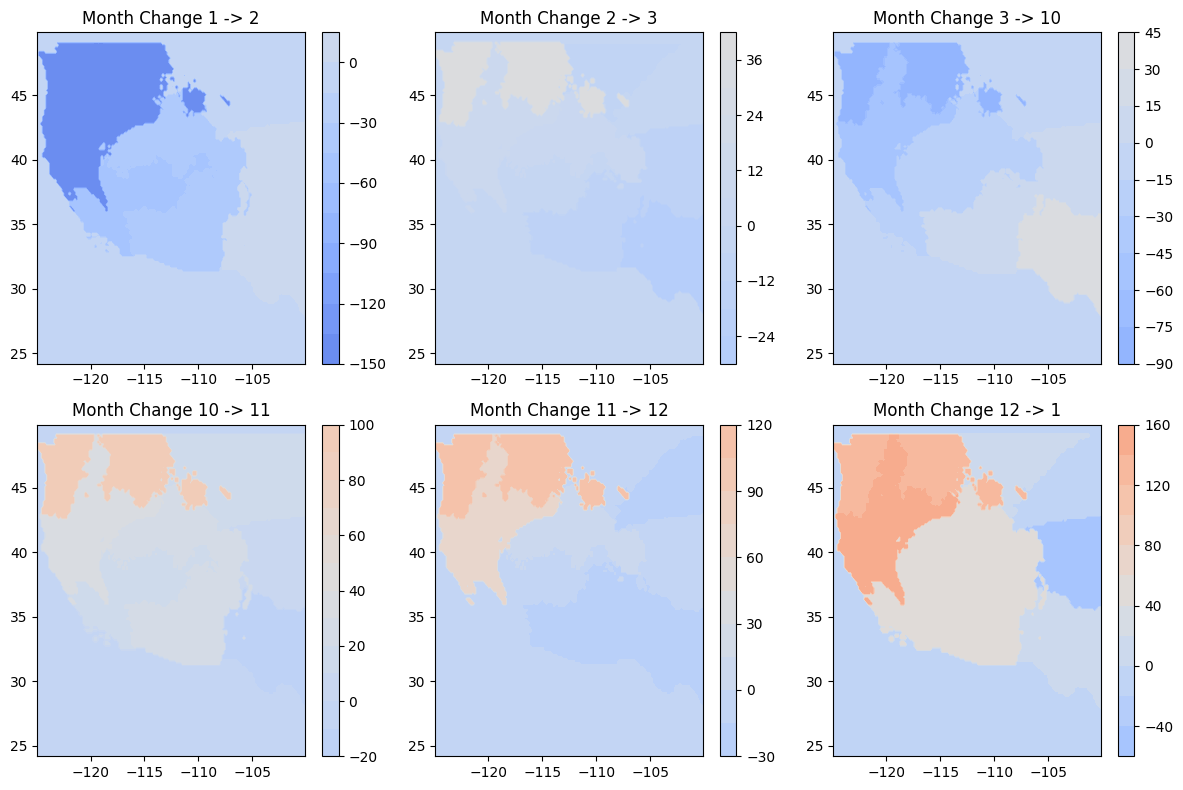

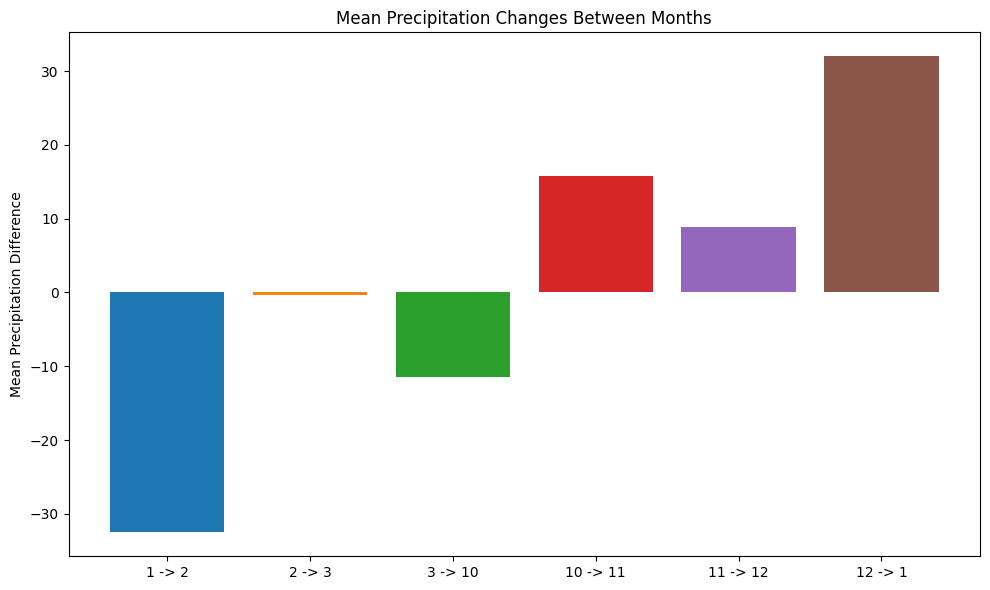

In [ ]:

# Step 3: Precipitation Change Between Months
# Plot the average precipitation difference between months
month_diff = np.diff(avg_clusters, axis=0)  # Difference between consecutive months

# Add the December (12) -> January (1) change
# Ensure that the dimensions match (reshape to match avg_clusters' shape)
dec_to_jan_diff = avg_clusters[0] - avg_clusters[-1]  # Calculate difference for month 12 -> 1

# Ensure dec_to_jan_diff has the same shape (3D) as avg_clusters
dec_to_jan_diff = np.expand_dims(dec_to_jan_diff, axis=0)  # Adding an extra dimension for time

# Append the December->January difference to the month_diff array
month_diff = np.concatenate([month_diff, dec_to_jan_diff], axis=0)

# Find the global min and max across all month-to-month differences
global_min = np.min(month_diff)
global_max = np.max(month_diff)

# plt.figure(figsize=(12, 8))

plt.contourf(xx, yy, clusters, levels=10, cmap="coolwarm")

# Now plotting the changes, including Dec->Jan
plt.figure(figsize=(12, 8))
for i, (current_month, next_month) in enumerate(zip(relevant_months[:-1], relevant_months[1:])):
    plt.subplot(2, 3, i + 1)
    xx, yy = np.meshgrid(lon, lat)
    # Use global_min and global_max for consistent color scaling
    c = plt.contourf(xx, yy, month_diff[i], levels=10, cmap="coolwarm", vmin=global_min, vmax=global_max)
    plt.colorbar(c)
    plt.title(f"Month Change {current_month} -> {next_month}")

# Add the December (12) -> January (1) plot
plt.subplot(2, 3, len(relevant_months))  # Last subplot for Dec->Jan
c = plt.contourf(xx, yy, month_diff[-1], levels=10, cmap="coolwarm", vmin=global_min, vmax=global_max)
plt.colorbar(c)
plt.title("Month Change 12 -> 1")

plt.tight_layout()
plt.show()

# Summarize the changes with bar plots
plt.figure(figsize=(10, 6))
for i, (current_month, next_month) in enumerate(zip(relevant_months[:-1], relevant_months[1:])):
    # Calculate the mean difference across the latitude and longitude dimensions
    mean_diff = np.mean(month_diff[i], axis=(0, 1))  # Mean across latitude and longitude
    plt.bar(f"{current_month} -> {next_month}", mean_diff)

# Add the December (12) -> January (1) plot
mean_diff_dec_to_jan = np.mean(month_diff[-1], axis=(0, 1))
plt.bar("12 -> 1", mean_diff_dec_to_jan)

plt.ylabel("Mean Precipitation Difference")
plt.title("Mean Precipitation Changes Between Months")
plt.tight_layout()
plt.show()


normalize the data per region/cluster, so that the percent change from baseline ppt is more clear.